In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cpa
import os

from tqdm import tqdm

from utils import set_seed

Global seed set to 0


In [4]:
set_seed(0)

In [5]:
batch_size = 4096

## Load data

In [6]:
adata = sc.read(
    "/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url="https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

In [7]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

## Data splits

In [8]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_celltype = ["Fibroblast"]
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    #is_holdout_ct = adata.obs["coarse_type"].isin(holdout_celltype)
    is_holdout_ct = adata.obs['coarse_type']!="Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [9]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [10]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [11]:
adata.obs['data_split'] = 'train'
adata.obs.iloc[val_idx, adata.obs.columns.get_loc('data_split')] = 'valid'
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('data_split')] = 'ood'

## Model selection

In [12]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [13]:
model_class = 'cpa'

In [14]:
adata.X = adata.layers['counts'].copy()

In [15]:
adata.obs['dose'] = 1.0 # NOTE: dummy dose for compatibility with CPA model

# Set perturbation column to 'perturbed' for cells in CRC region, REF and TVA are controls
adata.obs['perturbation'] = 'ctrl'
mask = np.zeros(adata.n_obs, dtype=bool)
mask[is_tumor_region] = True
adata.obs.loc[mask, "perturbation"] = 'perturbed'

In [16]:
adata.obs[domains_key].value_counts()

typ
242_TVA    286784
242_CRC     89908
242_REF     44002
Name: count, dtype: int64

In [17]:
cpa.CPA.setup_anndata(adata,
                      perturbation_key=domains_key,#'perturbation',
                      control_group='242_REF',#'ctrl',
                      dosage_key='dose',
                      categorical_covariate_keys=[labels_key],
                      is_count_data=True,
                      max_comb_len=1,
                     )

100%|██████████| 420694/420694 [00:00<00:00, 1668494.97it/s]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [18]:
model_params = {
    "n_latent": 64,
    "recon_loss": "nb",
    "doser_type": "linear",
    "n_hidden_encoder": 128,
    "n_layers_encoder": 2,
    "n_hidden_decoder": 512,
    "n_layers_decoder": 2,
    "use_batch_norm_encoder": True,
    "use_layer_norm_encoder": False,
    "use_batch_norm_decoder": False,
    "use_layer_norm_decoder": True,
    "dropout_rate_encoder": 0.0,
    "dropout_rate_decoder": 0.1,
    "variational": False,
    "seed": 6977,
}

trainer_params = {
    "n_epochs_kl_warmup": None,
    "n_epochs_pretrain_ae": 30,
    "n_epochs_adv_warmup": 50,
    "n_epochs_mixup_warmup": 0,
    "mixup_alpha": 0.0,
    "adv_steps": None,
    "n_hidden_adv": 64,
    "n_layers_adv": 3,
    "use_batch_norm_adv": True,
    "use_layer_norm_adv": False,
    "dropout_rate_adv": 0.3,
    "reg_adv": 20.0,
    "pen_adv": 5.0,
    "lr": 0.0003,
    "wd": 4e-07,
    "adv_lr": 0.0003,
    "adv_wd": 4e-07,
    "adv_loss": "cce",
    "doser_lr": 0.0003,
    "doser_wd": 4e-07,
    "do_clip_grad": True,
    "gradient_clip_value": 1.0,
    "step_size_lr": 10,
}

In [19]:
model = cpa.CPA(adata=adata,
                split_key='data_split',
                train_split='train',
                valid_split='valid',
                test_split='ood',
                **model_params,
               )

Global seed set to 6977


In [20]:
#save_path = f'{base_path}/cpa/lightning_logs/Kang/'
#save_path = f'{base_path}/cpa/lightning_logs/CRC_no_covariates/'
#save_path = f'{base_path}/cpa/lightning_logs/CRC_Fibroblast/'
save_path = f'{base_path}/cpa/lightning_logs/CRC_three_domains/'

In [25]:
model.train(max_epochs=100,
            use_gpu=True,
            batch_size=batch_size,
            plan_kwargs=trainer_params,
            early_stopping_patience=5,
            check_val_every_n_epoch=5,
            save_path=save_path,
           )

100%|██████████| 3/3 [00:00<00:00, 20.06it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 5/100:   4%|▍         | 4/100 [00:55<22:25, 14.02s/it, v_num=1, recon=433, r2_mean=0.639, adv_loss=0.821, acc_pert=0.84, acc_coarse_type=0.872] 


Epoch 00004: cpa_metric reached. Module best state updated.


Epoch 10/100:   9%|▉         | 9/100 [02:09<21:41, 14.30s/it, v_num=1, recon=422, r2_mean=0.663, adv_loss=0.598, acc_pert=0.872, acc_coarse_type=0.892, val_recon=432, disnt_basal=0.987, disnt_after=1.91, val_r2_mean=0.651, val_KL=nan]


Epoch 00009: cpa_metric reached. Module best state updated.


...

Epoch 80/100:  79%|███████▉  | 79/100 [19:34<05:07, 14.65s/it, v_num=1, recon=400, r2_mean=0.675, adv_loss=1.94, acc_pert=0.334, acc_coarse_type=0.773, val_recon=409, disnt_basal=0.731, disnt_after=1.91, val_r2_mean=0.662, val_KL=nan]
disnt_basal = 0.7320953005309525
disnt_after = 1.9103268201392627
val_r2_mean = 0.6126005014952491
val_r2_var = 0.5488230473854963
Epoch 90/100:  89%|████████▉ | 89/100 [22:05<02:41, 14.64s/it, v_num=1, recon=399, r2_mean=0.685, adv_loss=1.94, acc_pert=0.334, acc_coarse_type=0.773, val_recon=404, disnt_basal=0.744, disnt_after=1.91, val_r2_mean=0.672, val_KL=nan]
disnt_basal = 0.7326590565102764
disnt_after = 1.9103355563145126
val_r2_mean = 0.6341633505680981
val_r2_var = 0.5796382760300356
Epoch 95/100:  94%|█████████▍| 94/100 [23:20<01:27, 14.64s/it, v_num=1, recon=398, r2_mean=0.685, adv_loss=1.94, acc_pert=0.334, acc_coarse_type=0.773, val_recon=405, disnt_basal=0.733, disnt_after=1.91, val_r2_mean=0.634, val_KL=nan]


Epoch 00094: cpa_metric reached. Module best state updated.


Epoch 100/100:  99%|█████████▉| 99/100 [24:35<00:14, 14.67s/it, v_num=1, recon=398, r2_mean=0.686, adv_loss=1.93, acc_pert=0.335, acc_coarse_type=0.773, val_recon=405, disnt_basal=0.712, disnt_after=1.91, val_r2_mean=0.634, val_KL=nan]
disnt_basal = 0.7384160447624247
disnt_after = 1.9075597423345716
val_r2_mean = 0.6436733137158787
val_r2_var = 0.5624421526403988
Epoch 100/100: 100%|██████████| 100/100 [24:53<00:00, 15.62s/it, v_num=1, recon=398, r2_mean=0.683, adv_loss=1.92, acc_pert=0.336, acc_coarse_type=0.773, val_recon=405, disnt_basal=0.738, disnt_after=1.91, val_r2_mean=0.644, val_KL=nan]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [24:53<00:00, 14.93s/it, v_num=1, recon=398, r2_mean=0.683, adv_loss=1.92, acc_pert=0.336, acc_coarse_type=0.773, val_recon=405, disnt_basal=0.738, disnt_after=1.91, val_r2_mean=0.644, val_KL=nan]


## Analysis

In [21]:
model = cpa.CPA.load(dir_path=save_path,
                     adata=adata,
                     use_gpu=True)

INFO     File /data2/a330d/data/cellina-reproducibility/cpa/lightning_logs/CRC_three_domains/model.pt already      
         downloaded                                                                                                


100%|██████████| 420694/420694 [00:00<00:00, 1749433.16it/s]
Global seed set to 6977


In [51]:
from counterfactual_analysis import get_model_preds

results_adatas = {k: {} for k in ['cpa']}

In [52]:
return_normalized = False
counterfactual = False

In [54]:
results_adatas[model_class] = get_model_preds(
    model,
    adata,
    labels_key,
    model_class,
    return_normalized=return_normalized,
    counterfactual=counterfactual,
)

  0%|          | 0/7 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 2/2 [00:00<00:00, 24.75it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        



100%|██████████| 1/1 [00:00<00:00, 65.19it/s]

...

100%|██████████| 4/4 [00:00<00:00,  7.00it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 1/1 [00:00<00:00, 28.94it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        



100%|██████████| 7/7 [00:50<00:00,  7.16s/it]


In [57]:
df_base_path = '../results'

### Log-fold change (control v. perturbed)

In [62]:
from counterfactual_analysis import get_de_correlations

In [63]:
k = 50
plot = True
use_recon = False
normalize_counts = False

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:25<00:00,  3.70s/it]


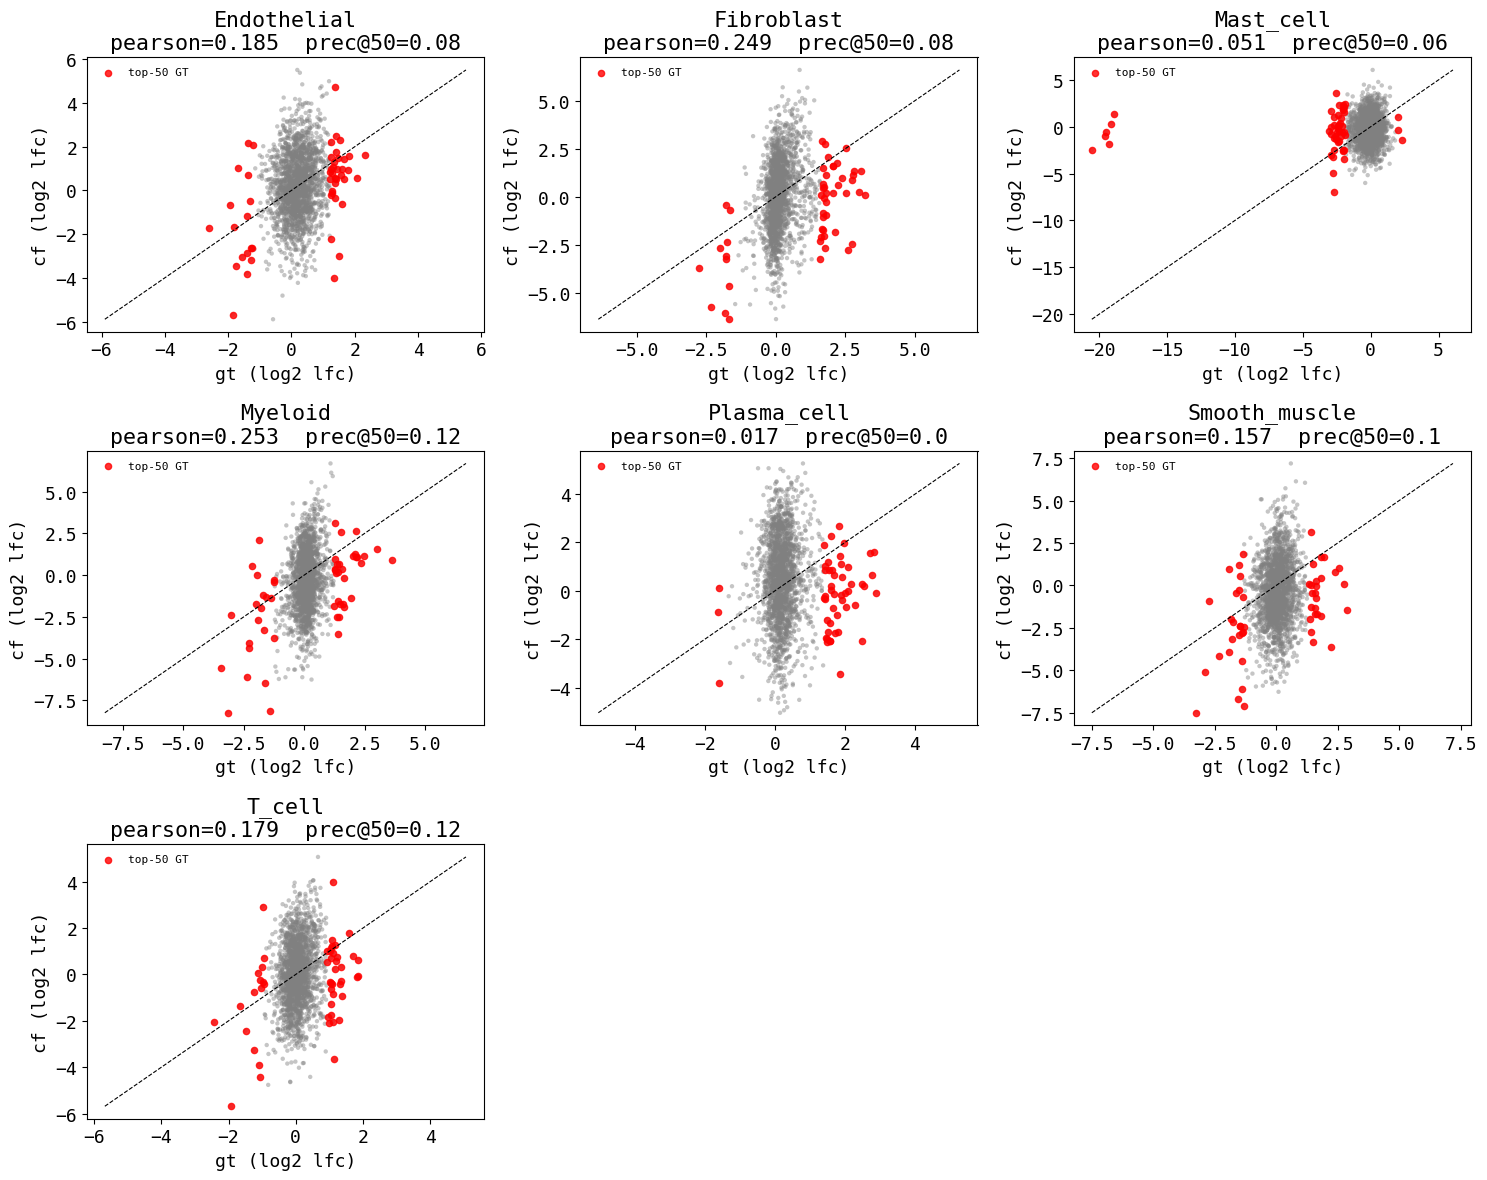

In [64]:
cpa_lfc, _ = get_de_correlations(results_adatas[model_class], k=k, plot=plot, use_recon=use_recon, normalize_counts=normalize_counts)

In [66]:
results_df = pd.DataFrame(cpa_lfc)
summary_df = results_df.groupby("celltype")[["pearson", "spearman"]].mean().reset_index()

# save for later use
summary_df.to_csv(os.path.join(df_base_path, "cpa_by_celltype_correlations.csv"), index=False)
summary_df

,celltype,pearson,spearman
0,Endothelial,0.184890,0.161050
1,Fibroblast,0.248782,0.283750
2,Mast_cell,0.050959,0.061355
3,Myeloid,0.253045,0.194344
4,Plasma_cell,0.017483,0.025433
5,Smooth_muscle,0.157454,0.134155
6,T_cell,0.179030,0.158940


### Observed vs. reconstructed DE

In [67]:
model.predict(adata, batch_size=batch_size)

100%|██████████| 103/103 [00:16<00:00,  6.08it/s]


In [68]:
from counterfactual_analysis import compare_observed_recon_lfc

agreements = compare_observed_recon_lfc(adata, labels_key, recon_key="CPA_pred")

100%|██████████| 8/8 [00:12<00:00,  1.62s/it]


In [69]:
agreements_df = pd.DataFrame.from_dict(agreements)
agreements_df.to_csv(os.path.join(df_base_path, "cpa_de.csv"))
agreements_df

,Fibroblast,Myeloid,Epithelial,T_cell,Smooth_muscle,Endothelial,Plasma_cell,Mast_cell
pearson,0.248606,0.248293,0.994508,0.169564,0.158743,0.170190,-0.018245,0.051531
spearman,0.282642,0.189073,0.985695,0.152182,0.130180,0.144658,0.000482,0.061012


### E-distances

In [70]:
from counterfactual_analysis import edist_observed_vs_recon

cpa_edists = edist_observed_vs_recon(adata, labels_key, recon_key="CPA_pred")

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:04<00:00,  1.99it/s]


In [71]:
cpa_edist = pd.DataFrame.from_dict(cpa_edists, orient='index')
cpa_edist.to_csv(os.path.join(df_base_path, "cpa_edist.csv"))
cpa_edist

,control,perturbed
Fibroblast,0.7049,6.1191
Myeloid,0.6525,4.7414
T_cell,0.8827,2.0978
Smooth_muscle,0.6056,4.2033
Endothelial,0.7556,3.3526
Plasma_cell,0.6723,4.9411
Mast_cell,0.7030,2.0130
